In [ ]:
from pathlib import Path
import shutil

# REPLACE 0cc79c26-3350-4e0b-af74-3578c3970157 classes with global ones
'''
In this dataset the obj.names is wrong. Laliotis told me to map like this:
0 flower
1 bud
2 green
3 pink
4 blue
'''
RAW_DATASET_ROOT = Path().cwd().parents[0] / "data" / "raw" / "yolo-classifier-compare" / "0cc79c26-3350-4e0b-af74-3578c3970157"
PROCESSED_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "yolo-classifier-compare"
(PROCESSED_DATASET_ROOT / "images").mkdir(parents=True, exist_ok=True)
(PROCESSED_DATASET_ROOT / "labels").mkdir(parents=True, exist_ok=True)

GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, 
                     "flower":1, "Flower":1,
                     "green":2, "Green":2, 
                     "pink":3, 
                     "purple":4,
                     "blue":5}


obj_names_path = RAW_DATASET_ROOT /"annotations/obj.names"
local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
for cls_name in local_cls_names:
  if cls_name not in GLOBAL_CLASS_DICT.keys():
    raise ValueError(f"class {cls_name} not in GLOBAL classes")

labels_dir = RAW_DATASET_ROOT / "annotations/obj_train_data"
# images_dir = dataset / "images"

local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(local_cls_names)}
print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")
counter = 0
for label_file in labels_dir.iterdir():
  new_lines = []

  with label_file.open(encoding = 'utf-8') as f:
    for line in f:
      parts = line.strip().split()
      local_cls_idx = int(parts[0])
      # if (local_cls_idx == 4):
      #   # print("iparxei 0")
      #   counter += 1
      global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
      parts[0] = str(global_cls_idx)
      new_lines.append(" ".join(parts))

  # write new label file
  out_label_path = PROCESSED_DATASET_ROOT / "labels" / label_file.name
  # print(out_label_path)

  '''
  out_label_path.write_text("\n".join(new_lines))
  '''

  # copy corresponding image
  img_name = label_file.with_suffix(".png").name
  src_img = RAW_DATASET_ROOT / "images" / img_name
  dst_img = PROCESSED_DATASET_ROOT / "images" / img_name
  # print(img_name)
  # print(src_img)
  # print(dst_img)

  '''
  if src_img.exists():
    shutil.copy(src_img ,dst_img)
    # pass
  else:
    raise ValueError(f"{src_img} does not exist")
  '''

# print(counter)

Local class names: ['flower', 'bud', 'green', 'pink', 'blue'] mapped with: {0: 1, 1: 0, 2: 2, 3: 3, 4: 5}


In [10]:
from pathlib import Path
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn

# ==========================================================
# LOAD classifier model
tracking_uri = Path("../experiments/mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_uri}")
run_id = "531b469fcd5f49ca86d611789277b437" # convnext-base
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)
print(run.data.params['data']) # this is string -> i have to use regular expr to parse mean/std -> ugly!
classifier = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
# classifier.to(DEVICE)
# classifier.eval()

print(classifier.classifier[2].weight.data)
torch.save(classifier.state_dict(), "convext-base-531b469fcd5f49ca86d611789277b437.pt")

{'root': PosixPath('data/processed/classification'), 'num_workers': 12, 'batch_size': 256, 'sampling': 'weighted', 'normalization': {'mean': [0.4291, 0.5388, 0.3654], 'std': [0.1859, 0.2121, 0.1966]}, 'augmentation': [{'_target_': 'torchvision.transforms.v2.RandomHorizontalFlip', 'p': 0.5}, {'_target_': 'torchvision.transforms.v2.RandomVerticalFlip', 'p': 0.5}, {'_target_': 'torchvision.transforms.v2.RandomRotation', 'degrees': 10}, {'_target_': 'torchvision.transforms.v2.ColorJitter', 'brightness': 0.05, 'contrast': 0.05, 'saturation': 0.01}]}


tensor([[-0.0098,  0.0037, -0.0094,  ...,  0.0068, -0.0078,  0.0029],
        [-0.0085, -0.0251, -0.0145,  ..., -0.0203,  0.0032,  0.0057],
        [-0.0146,  0.0103,  0.0024,  ..., -0.0056,  0.0128,  0.0048],
        [-0.0144, -0.0345, -0.0313,  ...,  0.0042,  0.0247, -0.0340],
        [-0.0014,  0.0522, -0.0084,  ..., -0.0368,  0.0051, -0.0228],
        [-0.0076,  0.0109, -0.0451,  ...,  0.0320,  0.0254,  0.0280]],
       device='cuda:0')


In [ ]:
from torchvision.models import convnext_base
import torch
import torch.nn as nn

model = convnext_base()
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 6)
# print(model.classifier[2].weight.data)
model.load_state_dict(torch.load("convext-base-531b469fcd5f49ca86d611789277b437.pt"))
print(model.classifier[2].weight.data)

tensor([[-0.0098,  0.0037, -0.0094,  ...,  0.0068, -0.0078,  0.0029],
        [-0.0085, -0.0251, -0.0145,  ..., -0.0203,  0.0032,  0.0057],
        [-0.0146,  0.0103,  0.0024,  ..., -0.0056,  0.0128,  0.0048],
        [-0.0144, -0.0345, -0.0313,  ...,  0.0042,  0.0247, -0.0340],
        [-0.0014,  0.0522, -0.0084,  ..., -0.0368,  0.0051, -0.0228],
        [-0.0076,  0.0109, -0.0451,  ...,  0.0320,  0.0254,  0.0280]])


In [10]:
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

from dataclasses import dataclass
from collections import Counter, defaultdict
from itertools import islice
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torchvision.transforms import v2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment
from src.utils.metrics import compute_classification_metrics_for_classifier_yolo_comparison
import mlflow
import mlflow.pytorch

# **SOS**: AUTO TO DATASET exei 4:blue anti gia 4:purple -> ta results tou classifier tha einai WRONG!!
# TEST_DATASET_ROOT = Path.home() / Path("BLUEBERRY_DATA/datasets/dataset-c834a7b7") 
# LABELS_DIR = TEST_DATASET_ROOT / "annotations" / "obj_train_data"

# dataset:  0cc79c26-3350-4e0b-af74-3578c3970157
TEST_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "yolo-classifier-compare"
IMAGES_DIR = TEST_DATASET_ROOT / "images"
LABELS_DIR = TEST_DATASET_ROOT / "labels"
MATCH_IOU= 0.5
NMS_IOU= 0.7 # YOLO was trained with IoU=0.7, but i think it is unrelated to NMS_IOU
CONF_THRESHOLD = 0.25 # default seems to be 0.25
DEVICE = "cuda:0"

LABEL_IDS = [0, 1, 2, 3, 4, 5]
CLASS_NAMES = ["bud", "flower", "green", "pink", "purple", "blue"]
CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS} # for use in classification report df

detector = YOLO("yolo_vs_classifier_v1.pt")
# detector.to(DEVICE)

# ==========================================================
# LOAD classifier model
tracking_uri = Path("../experiments/mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_uri}")
# run_id = "531b469fcd5f49ca86d611789277b437"
run_id = "a31e64b6476e4568ae8d10f70c3e2647" # best ?
# run_id = "ad29f3e37f5d406385a3856f1210c888"
# run_id = "1907811b55cb4759b58d9177a47d51b2" # res18mod
# run_id = "2efc87f7f09f4938ac6c9d9595f39a6d" # convnext stratified balanced
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)
print(run.data.params['data']) # this is string -> i have to use regular expr to parse mean/std -> ugly!
classifier = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
classifier.to(DEVICE)
classifier.eval()

mean = [0.4291, 0.5388, 0.3654]
std = [0.1859, 0.2121, 0.1966]
# mean = [0.3994, 0.51, 0.3541]
# std = [0.1831, 0.2149, 0.2105]

inference_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64)),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std) # depends on which model i choose , what dataset it was trained
])
# ==========================================================
@dataclass
class BBox:
  cls: int # index
  xc: float # normalized
  yc: float
  w: float
  h: float

  def to_xyxy(self, img_h, img_w) -> tuple[int, int, int, int]:
    x1 = (self.xc - self.w/2) * img_w # x_min
    y1 = (self.yc - self.h/2) * img_h # y_min
    x2 = (self.xc + self.w/2) * img_w # x_max
    y2 = (self.yc + self.h/2) * img_h # y_max
    return x1, y1, x2, y2 # NOTE: removed int(round()) to not lose subpixel precision.. I am not sure it is correct..
    # return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

def load_gt(label_file, img_h, img_w):
  '''
  gt bbox = (cls, [x1,y1,x2,y2])
  '''
  gt_boxes = []
  with label_file.open(encoding='utf-8') as f:
    for line in f:
      cls, xc, yc, w, h = map(float, line.split())
      box = BBox(int(cls),xc,yc,w,h)
      x1, y1, x2, y2 = box.to_xyxy(img_h, img_w)
      gt_boxes.append((int(cls), [x1, y1, x2, y2]))

  return gt_boxes

def compute_iou(boxA, boxB):
  xA1, yA1, xA2, yA2 = boxA
  xB1, yB1, xB2, yB2 = boxB

  inter_x1 = max(xA1, xB1)
  inter_y1 = max(yA1, yB1)
  inter_x2 = min(xA2, xB2)
  inter_y2 = min(yA2, yB2)

  inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
  areaA = (xA2 - xA1) * (yA2 - yA1)
  areaB = (xB2 - xB1) * (yB2 - yB1)

  # union_area = areaA + areaB - inter_area
  return inter_area / (areaA + areaB - inter_area + 1e-6)

def match_detections(gt_boxes, pred_boxes, iou_threshold=0.7):
  '''
  gt_boxes: np.array (N, 4) 
  pred_boxes: np.array (N, 4) 
  TODO: gt_boxes has dtype int64, and pred_boxes dtype float. Why? and Fix
  '''
  n_gt = len(gt_boxes)
  n_pred = len(pred_boxes)
  # print(gt_boxes.dtype, pred_boxes.dtype)
  # print(gt_boxes)
  # print(pred_boxes)

  if n_gt == 0 or n_pred == 0:
    return [], list(range(n_gt)), list(range(n_pred))

  # IoU matrix
  iou_matrix = np.zeros((n_gt, n_pred), dtype=np.float32)
  for i, gt in enumerate(gt_boxes):
    for j, pred in enumerate(pred_boxes):
      iou_matrix[i, j] = compute_iou(gt, pred)

  # Hungarian minimizes cost
  # so convert IoU -> cost
  cost_matrix = 1.0 - iou_matrix
  gt_indices, pred_indices = linear_sum_assignment(cost_matrix)
  matches = []
  unmatched_gt = set(range(n_gt))
  unmatched_pred = set(range(n_pred))

  for gt_idx, pred_idx in zip(gt_indices, pred_indices):
    iou_score = iou_matrix[gt_idx, pred_idx]
    if iou_score >= iou_threshold:
      matches.append((gt_idx, pred_idx, iou_score))

      unmatched_gt.discard(gt_idx)
      unmatched_pred.discard(pred_idx)

  return (matches, list(unmatched_gt), list(unmatched_pred))

{'root': PosixPath('data/processed/classification'), 'num_workers': 12, 'batch_size': 256, 'sampling': 'weighted', 'normalization': {'mean': [0.4291, 0.5388, 0.3654], 'std': [0.1859, 0.2121, 0.1966]}, 'augmentation': [{'_target_': 'torchvision.transforms.v2.RandomHorizontalFlip', 'p': 0.5}, {'_target_': 'torchvision.transforms.v2.RandomVerticalFlip', 'p': 0.5}, {'_target_': 'torchvision.transforms.v2.RandomRotation', 'degrees': 10}, {'_target_': 'torchvision.transforms.v2.ColorJitter', 'brightness': 0.05, 'contrast': 0.05, 'saturation': 0.01}]}


In [11]:
# # from IPython.display import display
# for label_file in islice(LABELS_DIR.iterdir(), 2):

#   img_file = IMAGES_DIR / label_file.with_suffix('.png').name
#   img_rgb = Image.open(img_file).convert("RGB")
#   img_h, img_w = img_rgb.height, img_rgb.width
#   assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

#   gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
#   print(len(gt_boxes))
  
#   results = detector.predict(source=img_file, conf=CONF_THRESHOLD, iou=NMS_IOU, device=DEVICE, verbose=False)
#   result = results[0]
#   pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
#   pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
#   pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)
#   # im_array = result.plot()  # display to screen
#   # im = Image.fromarray(im_array)
#   # display(im)
#   print(len(pred_boxes))
#   plt.figure(figsize=(10,10))
#   plt.imshow(result.plot())
#   plt.axis("off")
#   plt.show()

In [12]:
from enum import Enum
class COMPARE_TYPE(Enum):
  GT = 0
  YOLO_DETECTION = 1

comparison = COMPARE_TYPE.YOLO_DETECTION
interesting_images_paths = [] # images to visualize
interesting_images_info = [] # images to visualize
outputs = []
# total_gt_boxes = 0
# img_h, img_w = 2048, 1536
# for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 50):
for label_file in tqdm(LABELS_DIR.iterdir()):
  img_file = IMAGES_DIR / label_file.with_suffix('.png').name
  # print(img_file)
  img_rgb = Image.open(img_file).convert("RGB")
  img_h, img_w = img_rgb.height, img_rgb.width
  assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

  gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
  # total_gt_boxes += len(gt_boxes)
  results = detector.predict(source=img_file, conf=CONF_THRESHOLD, iou=NMS_IOU, device=DEVICE, verbose=False)
  result = results[0]
  pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
  pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
  pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)
  # print(pred_boxes.dtype)
  # print(np.array([t[1] for t in gt_boxes]).shape)
  
  matches, unmatched_gt, unmatched_pred = match_detections(
    np.array([t[1] for t in gt_boxes], dtype=np.float32), # extract [x1,y1,x2,y2] from each (label, [x1,y1,x2,y2])
    pred_boxes,
    iou_threshold=MATCH_IOU
  )
  # print(f"number of matches: {len(matches)}")
  for gt_idx, pred_idx, iou_score in matches:
    gt_cls, gt_box = gt_boxes[gt_idx]
    yolo_pred = int(pred_cls[pred_idx])
    yolo_conf = float(pred_conf[pred_idx])
    # print(f"gt index: {gt_idx} pred index: {pred_idx}")
    # print("gt class:", gt_cls)
    # print("gt box:", gt_box)
    # print(f"pred box: {pred_boxes[pred_idx]}")

    if comparison == COMPARE_TYPE.GT:
      crop = img_rgb.crop(gt_box) # crop the gt box
    elif comparison == COMPARE_TYPE.YOLO_DETECTION:
      crop = img_rgb.crop(pred_boxes[pred_idx]) # crop the detected bbox
    if crop.width < 2 or crop.height < 2:
      continue

    crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
      logits = classifier(crop_transformed).cpu()
      classifier_probs = nn.Softmax(dim=1)(logits).cpu() # (1, n_classes)
    classifier_pred = logits.argmax(dim=1).item()
    classifier_conf = classifier_probs[:, classifier_pred].item()

    info = {
      "gt": gt_cls,
      "yolo_pred": yolo_pred,
      "yolo_conf": 100*yolo_conf,
      "classifier_pred": classifier_pred,
      "classifier_conf": 100*classifier_conf,
      "iou": iou_score,
      "gt_box": gt_box,
      "pred_box": pred_boxes[pred_idx].tolist(),
      # "img_name" : img_file.name
      # "match": True,
      # "iou": best_iou
    }
    outputs.append(info)

    '''
    # keep images for viz that contain a match corresponding to blue class
    if gt_cls == 5:
      interesting_images_paths.append(img_file)
      interesting_images_info.append(info)
      # interesting_images[img_file].append(info)
    '''
  
  '''
  # keep only images with blueberries
  if Counter([t[0] for t in gt_boxes])[5] > 100:
    print(f"{i} : {label_file.name}")
    # interesting_images.append((img_rgb.copy(), image_matches, img_file.name))
  '''

  # print(np.array([t[1] for t in gt_boxes]))
  # print([t[1] for t in gt_boxes])

12it [00:02,  5.36it/s]


KeyboardInterrupt: 

In [ ]:
print(len(interesting_images_info))

0


In [ ]:
# import matplotlib.patches as patches
# GTCLASS = 2
# print(f"Number of gt={GTCLASS} bboxes that matched = {sum(1 for info in outputs if info['gt'] == GTCLASS)}")
# print(f"Total gt boxes = {total_gt_boxes}")

# def visualize_image(image_paths:list, images_info:list, title:str=""):
#   for img_path, info in zip(image_paths, images_info):
#     fig, ax = plt.subplots(1, figsize=(14, 20))
#     img = Image.open(img_path).convert("RGB")
#     ax.imshow(img)
#     x1, y1, x2, y2 = info["pred_box"]

#     gt_cls = info["gt"]
#     yolo_cls = info["yolo_pred"]
#     clf_cls = info["classifier_pred"]

#     rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='red', facecolor='none')
#     ax.add_patch(rect)
#     text = (
#       f"GT:{gt_cls} | "
#       f"Y:{yolo_cls} ({info['yolo_conf']:.1f}) | "
#       f"C:{clf_cls} ({info['classifier_conf']:.1f})"
#     )
#     ax.text(x1, y1-5, text, color="white", fontsize=6, verticalalignment='bottom', bbox=dict(facecolor='red', alpha=0.5, pad=1, edgecolor="none"))

#   ax.set_title(title)
#   plt.axis("off")
#   plt.show()

# visualize_image(interesting_images_paths, interesting_images_info)

true labels = [0 1 2 3 5], classifier = [0 1 2 3 4 5], yolo = [0 1 2 3 4]
NMS_IOU = 0.7, MATCH_IOU = 0.5, confidence = 0.25
CLASSIFIER: 
acc 68.51% | balanced_acc: 57.49% | f1_macro: 38.48% | f1_weighted: 69.56% | precision_macro: 43.52% | precision_weighted: 74.56% | recall_macro: 47.91% | recall_weighted: 68.51%
YOLO:
acc 57.01% | balanced_acc: 47.60% | f1_macro: 23.71% | f1_weighted: 56.82% | precision_macro: 20.84% | precision_weighted: 61.70% | recall_macro: 39.67% | recall_weighted: 57.01%


/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,precision,recall,f1-score,support
bud,15.020,88.372,25.676,43
flower,31.293,58.442,40.761,385
green,84.605,80.169,82.327,3071
pink,56.067,21.372,30.947,627
purple,0.000,0.000,0.000,0
blue,74.138,39.091,51.190,110
accuracy,68.508,68.508,68.508,0
macro avg,43.520,47.908,38.484,4236
weighted avg,74.557,68.508,69.561,4236


,precision,recall,f1-score,support
bud,21.893,86.047,34.906,43
flower,20.985,85.195,33.676,385
green,82.164,66.754,73.662,3071
pink,0.000,0.000,0.000,627
purple,0.000,0.000,0.000,0
blue,0.000,0.000,0.000,110
accuracy,57.011,57.011,57.011,0
macro avg,20.841,39.666,23.707,4236
weighted avg,61.697,57.011,56.818,4236


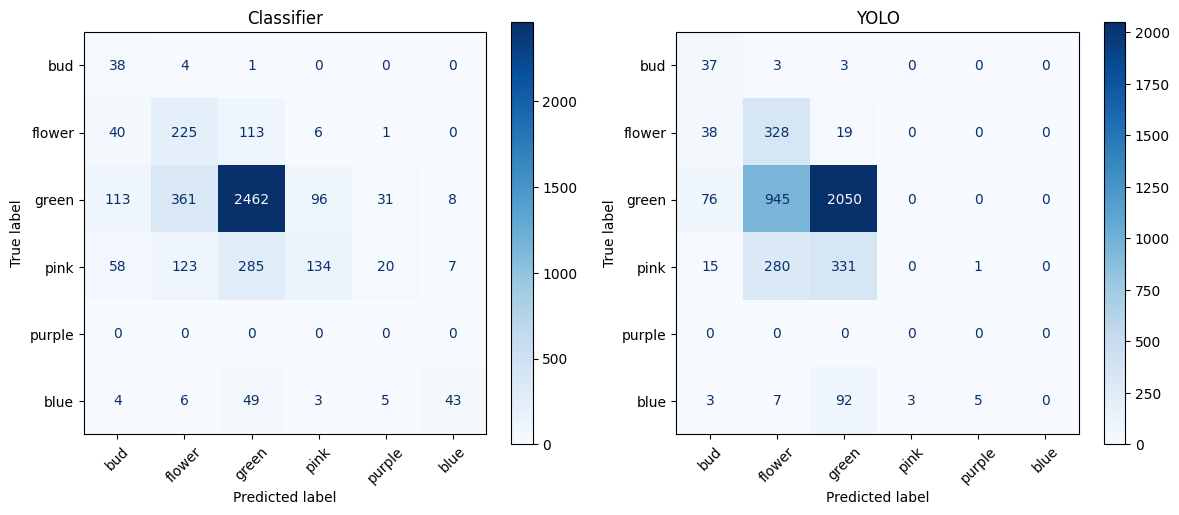

In [ ]:
y_true = []
y_yolo = []
y_classifier = []
for d in outputs:

  y_true.append(d['gt'])
  y_yolo.append(d['yolo_pred'])
  y_classifier.append(d['classifier_pred'])

print(f"true labels = {np.unique(y_true)}, classifier = {np.unique(y_classifier)}, yolo = {np.unique(y_yolo)}")

classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_classifier, y_true, LABEL_IDS)
classifier_classification_report = classifier_metrics['classification_report']
yolo_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_yolo, y_true, LABEL_IDS)
yolo_classification_report = yolo_metrics['classification_report']
print(f"NMS_IOU = {NMS_IOU}, MATCH_IOU = {MATCH_IOU}, confidence = {CONF_THRESHOLD}")

print(f"CLASSIFIER: ")
print(
  f"acc {classifier_metrics['acc']:.2f}% | "
  f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
  f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | "
  f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
  f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | "
  f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
  f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | "
  f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
)

print(f"YOLO:")
print(
  f"acc {yolo_metrics['acc']:.2f}% | "
  f"balanced_acc: {yolo_metrics['balanced_acc']:.2f}% | "
  f"f1_macro: {yolo_metrics['f1_macro']:.2f}% | "
  f"f1_weighted: {yolo_metrics['f1_weighted']:.2f}% | "
  f"precision_macro: {yolo_metrics['precision_macro']:.2f}% | "
  f"precision_weighted: {yolo_metrics['precision_weighted']:.2f}% | "
  f"recall_macro: {yolo_metrics['recall_macro']:.2f}% | "
  f"recall_weighted: {yolo_metrics['recall_weighted']:.2f}%"
)

METRIC_COLUMNS = ["precision", "recall", "f1-score"]
classifier_df = pd.DataFrame(classifier_classification_report).transpose()
classifier_df = classifier_df.rename(index=CLASS_MAPPING)
yolo_df = pd.DataFrame(yolo_classification_report).transpose()
yolo_df = yolo_df.rename(index=CLASS_MAPPING)
for df in [classifier_df, yolo_df]:
  df[METRIC_COLUMNS] = df[METRIC_COLUMNS] * 100
  df["support"] = df["support"].astype(int)

display(classifier_df.style.format(precision=3).set_caption("Classifier"))
display(yolo_df.style.format(precision=3).set_caption("YOLO"))


classifier_conf_matrix = classifier_metrics['confusion_matrix']
fig, ax = plt.subplots(1, 2, figsize=(12,5))
disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
# disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
disp_conf_matrix.plot(ax=ax[0], cmap=plt.cm.Blues, xticks_rotation=45)
ax[0].set_title("Classifier")

yolo_conf_matrix = yolo_metrics['confusion_matrix']
disp_conf_matrix = ConfusionMatrixDisplay(yolo_conf_matrix, display_labels=CLASS_NAMES)
disp_conf_matrix.plot(ax=ax[1], cmap=plt.cm.Blues, xticks_rotation=45)
ax[1].set_title("YOLO")
plt.tight_layout()
plt.show()

In [ ]:
# res18mod
acc 65.53% | balanced_acc: 59.71% | f1_macro: 38.84% | f1_weighted: 67.07% | precision_macro: 47.35% | precision_weighted: 78.18% | recall_macro: 49.76% | recall_weighted: 65.53%
YOLO:
acc 57.01% | balanced_acc: 47.60% | f1_macro: 23.71% | f1_weighted: 56.82% | precision_macro: 20.84% | precision_weighted: 61.70% | recall_macro: 39.67% | recall_weighted: 57.01%

# First convnext
CLASSIFIER: 
acc 66.41% | balanced_acc: 59.32% | f1_macro: 37.90% | f1_weighted: 67.80% | precision_macro: 46.40% | precision_weighted: 77.18% | recall_macro: 49.43% | recall_weighted: 66.41%
YOLO:
acc 57.01% | balanced_acc: 47.60% | f1_macro: 23.71% | f1_weighted: 56.82% | precision_macro: 20.84% | precision_weighted: 61.70% | recall_macro: 39.67% | recall_weighted: 57.01%

Classifier
 	precision	recall	f1-score	support
bud	13.669	88.372	23.676	43
flower	27.282	71.429	39.483	385
green	86.252	76.815	81.261	3071
pink	66.423	14.514	23.822	627
purple	0.000	0.000	0.000	0
blue	84.746	45.455	59.172	110
accuracy	66.407	66.407	66.407	0
macro avg	46.395	49.431	37.902	4236
weighted avg	77.182	66.407	67.804	4236

YOLO
 	precision	recall	f1-score	support
bud	21.893	86.047	34.906	43
flower	20.985	85.195	33.676	385
green	82.164	66.754	73.662	3071
pink	0.000	0.000	0.000	627
purple	0.000	0.000	0.000	0
blue	0.000	0.000	0.000	110
accuracy	57.011	57.011	57.011	0
macro avg	20.841	39.666	23.707	4236
weighted avg	61.697	57.011	56.818	4236



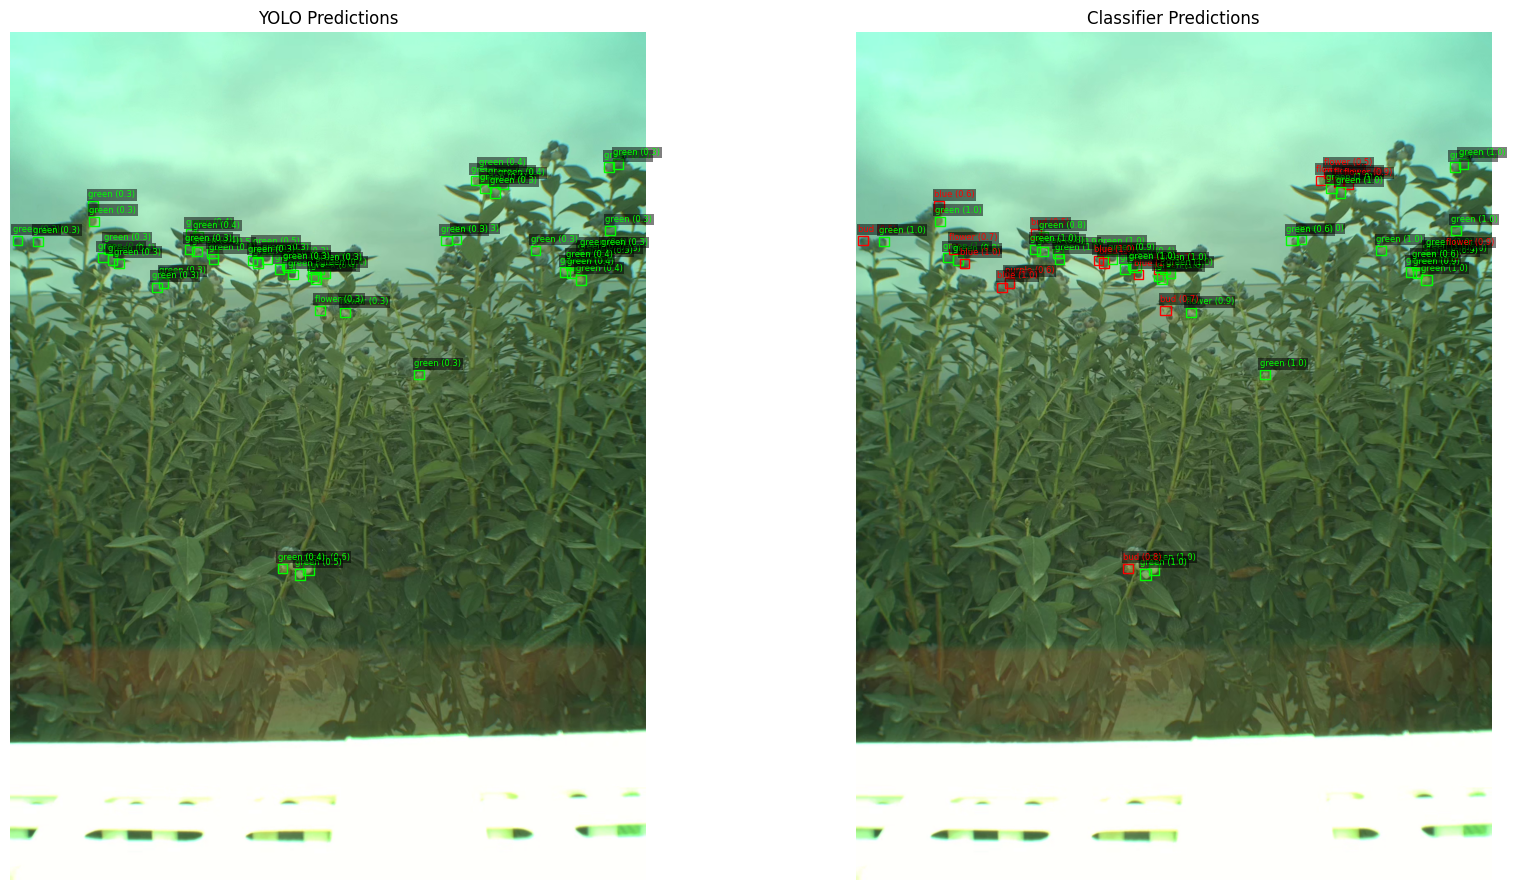

In [17]:
# slice = 12,13 -> some pinks
# contain blue -> 23, 80, 130,
SHOW_GROUND_TRUTH = False
VIS_LIMIT = 5
show_counter = 0
for label_file in islice(LABELS_DIR.iterdir(), 130, 131):
# for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 1, 200):
# for label_file in tqdm(LABELS_DIR.iterdir()):
  img_file = IMAGES_DIR / label_file.with_suffix('.png').name
  # print(img_file)
  img_rgb = Image.open(img_file).convert("RGB")
  img_h, img_w = img_rgb.height, img_rgb.width
  assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

  gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
  results = detector.predict(source=img_file, conf=CONF_THRESHOLD, iou=NMS_IOU, device=DEVICE, verbose=False)
  result = results[0]
  pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
  pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
  pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)

  # Create side-by-side figure
  fig, ax = plt.subplots(1, 2, figsize=(18, 9))
  # Show same image on both sides
  ax[0].imshow(img_rgb)
  ax[1].imshow(img_rgb)
  ax[0].set_title("YOLO Predictions")
  ax[1].set_title("Classifier Predictions")
  ax[0].axis("off")
  ax[1].axis("off")

  if SHOW_GROUND_TRUTH:
    for gt_label, gt_box in gt_boxes:
      x1,y1,x2,y2 = gt_box
      rect_gt = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor="cyan", linestyle="--", facecolor="none")
      ax[0].add_patch(rect_gt)
      ax[0].text( x1, y1 - 5, f"{CLASS_NAMES[gt_label]}", color="cyan", fontsize=10, bbox=dict(facecolor="black", alpha=0.7))

  CONTAINS_BLUE_PRED = False
  for box, yolo_cls, yolo_conf in zip(pred_boxes, pred_cls, pred_conf):
    x1, y1, x2, y2 = box

    crop = img_rgb.crop(box)
    crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
      logits = classifier(crop_transformed).cpu()
      classifier_probs = nn.Softmax(dim=1)(logits).cpu() # (1, n_classes)
    classifier_pred = logits.argmax(dim=1).item()
    classifier_conf = classifier_probs[:, classifier_pred].item()

    if classifier_pred == 5:
      # print(i)
      CONTAINS_BLUE_PRED = True
    # print(classifier_pred, type(classifier_pred))

    # =========================
    # LEFT IMAGE (YOLO)
    # =========================
    rect_yolo = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='lime', facecolor='none')
    ax[0].add_patch(rect_yolo)
    text = (
      f"{CLASS_NAMES[yolo_cls.astype(np.int64)]} ({yolo_conf:.1f})"
      # f"GT:{gt_cls} | "
      # f"{CLASS_NAMES[yolo_cls]} ({yolo_conf:.1f}) | "
      # f"C:{classifier_pred} ({classifier_conf:.1f})"
    )
    ax[0].text(x1, y1-5, text, color="lime", fontsize=6, verticalalignment='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor="none"))
    # =========================
    # RIGHT IMAGE (Classifier)
    # =========================
    color = "lime" if classifier_pred == yolo_cls else "red"
    rect_cls = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor=color, facecolor='none')
    ax[1].add_patch(rect_cls)
    text = (
      f"{CLASS_NAMES[classifier_pred]} ({classifier_conf:.1f})"
      # f"GT:{gt_cls} | "
      # f"Y:{yolo_cls} ({info['yolo_conf']:.1f}) | "
      # f"{CLASS_NAMES[classifier_pred]} ({classifier_conf:.1f})"
    )
    ax[1].text(x1, y1-5, text, color=color, fontsize=6, verticalalignment='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor="none"))

  # if CONTAINS_BLUE_PRED and show_counter<VIS_LIMIT:
    # print("blue")
    # show_counter += 1
  plt.tight_layout()
  plt.show()

## SAHI Comparison

In [ ]:
from sahi import AutoDetectionModel, Category
from sahi.predict import get_sliced_prediction, ObjectPrediction
detector = AutoDetectionModel.from_pretrained(
  model_type="ultralytics",
  model_path="../twostage/best.pt",
  confidence_threshold=CONF_THRESHOLD,
  device=DEVICE
)
# detection_model.model # the yolo model

for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 1):
# for label_file in tqdm(LABELS_DIR.iterdir()):
  img_file = IMAGES_DIR / label_file.with_suffix('.png').name
  # print(img_file)
  img_rgb = Image.open(img_file).convert("RGB")
  img_h, img_w = img_rgb.height, img_rgb.width
  assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"
  gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])

  # results = detector.predict(source=img_file, conf=CONF_THRESHOLD, iou=NMS_IOU, device=DEVICE, verbose=False)
  # result = results[0]
  # pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
  # pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
  # pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)

  result = get_sliced_prediction(
    image=str(img_file), # str(TEST_IMAGE_PATH),
    detection_model=detector,
    slice_height=640,
    slice_width=640,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    postprocess_type="NMS", # defalt: GREEDYNMM
    postprocess_match_metric="IOU", #default:IOS
    postprocess_match_threshold=0.5
  )
  for pred in result.object_prediction_list:
    bbox = pred.bbox
    print(pred.category)
    print(pred.score)
  print(result.object_prediction_list)
  # bbox = pred.bbox

Performing prediction on 12 slices.
Category: <id: 0, name: item>
PredictionScore: <value: 0.7568625807762146>
Category: <id: 0, name: item>
PredictionScore: <value: 0.7277109622955322>
Category: <id: 0, name: item>
PredictionScore: <value: 0.7261455655097961>
Category: <id: 0, name: item>
PredictionScore: <value: 0.7211653590202332>
Category: <id: 0, name: item>
PredictionScore: <value: 0.7188910841941833>
Category: <id: 0, name: item>
PredictionScore: <value: 0.7159423232078552>
Category: <id: 0, name: item>
PredictionScore: <value: 0.7121458649635315>
Category: <id: 0, name: item>
PredictionScore: <value: 0.6999610066413879>
Category: <id: 0, name: item>
PredictionScore: <value: 0.6954023241996765>
Category: <id: 0, name: item>
PredictionScore: <value: 0.6931254863739014>
Category: <id: 0, name: item>
PredictionScore: <value: 0.6897045373916626>
Category: <id: 0, name: item>
PredictionScore: <value: 0.6896159648895264>
Category: <id: 0, name: item>
PredictionScore: <value: 0.6892318

In [ ]:
# from PIL import ImageDraw
  # Copy for visualization
  # yolo_vis = img_rgb.copy()
  # clf_vis = img_rgb.copy()
  # yolo_draw = ImageDraw.Draw(yolo_vis)
  # clf_draw = ImageDraw.Draw(clf_vis)
    '''
    # -------------------------
    # Draw YOLO result
    # -------------------------
    yolo_draw.rectangle( [x1, y1, x2, y2], outline="lime", width=3)
    text = (
      f"Y:{yolo_cls} ({info['yolo_conf']:.1f}) | "
      f"C:{classifier_pred} ({classifier_conf:.1f})"
    )
    yolo_draw.text((x1, max(0, y1 - 15)), text, fill="lime")

    # -------------------------
    # Draw classifier result
    # -------------------------
    color = "lime" if classifier_pred == yolo_cls else "red"
    clf_draw.rectangle( [x1, y1, x2, y2], outline=color, width=3)
    text = (
      # f"Y:{yolo_cls} ({info['yolo_conf']:.1f}) | "
      f"C:{classifier_pred} ({classifier_conf:.1f})"
    )
    clf_draw.text( (x1, max(0, y1 - 15)), text, fill=color)
    '''

  '''
  # =========================
  # SIDE-BY-SIDE PLOT
  # =========================
  fig, ax = plt.subplots(1, 2, figsize=(14,20))

  ax[0].imshow(yolo_vis)
  ax[0].set_title("YOLO Predictions")
  ax[0].axis("off")
  ax[1].imshow(clf_vis)
  ax[1].set_title("Classifier Predictions on YOLO Crops")
  ax[1].axis("off")
  plt.tight_layout()
  plt.show()  
  '''

  '''
  # color logic
  same = (yolo_cls == classifier_pred)
  color = "lime" if same else "red"
  # -----------------
  # Draw bbox
  # -----------------
  draw.rectangle(box.tolist(), outline=color, width=3)
  # -----------------
  # Draw label
  # -----------------
  text = ( f"YOLO: {yolo_cls} ({yolo_conf:.2f}) | " f"CLF: {classifier_pred} ({classifier_conf:.2f})")
  draw.text((x1, max(0, y1 - 15)), text, fill=color)
  '''

'''
# =========================
# PLOT SIDE BY SIDE
# =========================

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img_rgb)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(vis_image)
ax[1].set_title("YOLO vs Classifier")
ax[1].axis("off")

plt.tight_layout()
plt.show()
'''

In [ ]:
# detector = YOLO("yolo_vs_classifier_v1.pt")
# print(detector.overrides)
print(detector.predictor.args)

task=detect
mode=predict
model=yolo_vs_classifier_v1.pt
data=/data/dataset_prep_cache/e7c5961371a9/data.yaml
epochs=100
time=None
patience=100
batch=1
imgsz=512
save=False
save_period=-1
cache=False
device=cuda:0
workers=8
project=None
name=None
exist_ok=False
pretrained=True
optimizer=auto
verbose=False
seed=0
deterministic=True
single_cls=False
rect=True
cos_lr=False
close_mosaic=10
resume=False
amp=True
fraction=1.0
profile=False
freeze=None
multi_scale=0.0
compile=False
overlap_mask=True
mask_ratio=4
dropout=0.0
val=True
split=val
save_json=False
conf=0.25
iou=0.7
max_det=300
half=False
dnn=False
plots=True
end2end=None
source=None
vid_stride=1
stream_buffer=False
visualize=False
augment=False
agnostic_nms=False
classes=None
retina_masks=False
embed=None
show=False
save_frames=False
save_txt=False
save_conf=False
save_crop=False
show_labels=True
show_conf=True
show_boxes=True
line_width=None
format=torchscript
keras=False
optimize=False
int8=False
dynamic=False
simplify=True
opset=

In [ ]:
detector = YOLO("yolo_vs_classifier_v1.pt")
print(detector.model.args)
print(detector.overrides)

{'task': 'detect', 'data': '/data/dataset_prep_cache/e7c5961371a9/data.yaml', 'imgsz': 512, 'single_cls': False, 'model': 'yolo_vs_classifier_v1.pt'}
{'task': 'detect', 'data': '/data/dataset_prep_cache/e7c5961371a9/data.yaml', 'imgsz': 512, 'single_cls': False, 'model': 'yolo_vs_classifier_v1.pt'}


### OLD implementations

In [ ]:
# '''
# SOS: Make sure the labels in the dataset I use for validation correspond to the global labels i have 0:bud, 1:flower , etc...
# '''
# outputs = []
# img_h, img_w = 2048, 1536
# for label_file in islice(LABELS_DIR.iterdir(), 1):
# # for label_file in LABELS_DIR.iterdir():
#   gt_boxes = load_gt(label_file, img_h, img_w)
#   img_file = IMAGES_DIR / label_file.with_suffix('.png').name
#   # print(img_file)
#   img_rgb = Image.open(img_file).convert("RGB")
#   # results = detector(img_rgb)
#   results = detector.predict(
#     source=img_file,
#     conf=CONF_THRESHOLD,
#     iou=IOU_THRESHOLD,
#     device=DEVICE,
#     verbose=False
#   )
#   result = results[0]
#   pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
#   pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
#   pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)
#   # print(pred_boxes)

#   # for each gt box find the prediction that corresponds to it
#   outputs_per_file = []
#   already_matched_pred_boxes = set()
#   for gt_cls, gt_box in gt_boxes:
#     # print(f"ground truth box: {gt_box}")
#     best_iou, best_j = 0, -1

#     for j, pbox in enumerate(pred_boxes):
#       if j in already_matched_pred_boxes:
#         continue

#       score = compute_iou(gt_box, pbox)
#       if score > best_iou:
#         best_iou = score
#         best_j = j
#         # print(f"best {j}, iou score: {score}")

#     # past that poing best_j contains the best matching predicted bbox to the gt
#     if best_iou < IOU_THRESHOLD:
#       # missed prediction, false negative?
#       outputs_per_file.append({
#         "gt": gt_cls,
#         "yolo_pred": None,
#         "yolo_conf": None,
#         "classifier_pred": None,
#         "classifier_conf": None,
#         "match": False,
#         "iou": None
#       })
#       # print("didn't match to any detection")
#       continue

#     already_matched_pred_boxes.add(best_j)
#     # print(f"==================================")

#     # YOLO class prediction
#     yolo_pred = int(pred_cls[best_j])
#     yolo_conf = float(pred_conf[best_j])

#     # TODO: feed the ground truth to the classifier
#     # -----------------------------
#     # Crop GT box for classifier
#     # -----------------------------
#     crop = img_rgb.crop(gt_box) # crop the gt box
#     # crop = img_rgb.crop(pred_boxes[best_j]) # crop the detected bbox
#     if crop.width < 2 or crop.height < 2:
#       continue

#     crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
#     with torch.no_grad():
#       logits = classifier(crop_transformed).cpu()
#     classifier_probs = nn.Softmax(dim=1)(logits).cpu() # (1, n_classes)
#     classifier_pred = logits.argmax(dim=1).item()
#     classifier_conf = classifier_probs[:, classifier_pred].item()
#     # print(logits)
#     # print(classifier_probs)
#     # print(classifier_pred)
#     # print(100*classifier_conf)

#     outputs_per_file.append({
#       "gt": gt_cls,
#       "yolo_pred": yolo_pred,
#       "yolo_conf": 100*yolo_conf,
#       "classifier_pred": classifier_pred,
#       "classifier_conf": 100*classifier_conf,
#       "match": True,
#       "iou": best_iou
#     })

#   outputs.extend(outputs_per_file)

In [ ]:
# len(outputs_per_file), len(outputs)
y_true = []
y_yolo = []
y_classifier = []
for d in outputs:
  if d['match']:

    y_true.append(d['gt'])
    y_yolo.append(d['yolo_pred'])
    y_classifier.append(d['classifier_pred'])

print(np.unique(y_true), np.unique(y_classifier), np.unique(y_yolo))

classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_classifier, y_true, LABEL_IDS)
classifier_per_class_report = classifier_metrics['classification_report']
yolo_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_yolo, y_true, LABEL_IDS)
yolo_per_class_report = yolo_metrics['classification_report']
print(f"IOU = {IOU_THRESHOLD}, confidence = {CONF_THRESHOLD}")

print(f"CLASSIFIER: ")
print(
  f"acc {classifier_metrics['acc']:.2f}% | "
  f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
  f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | "
  f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
  f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | "
  f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
  f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | "
  f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
)

print(f"YOLO:")
print(
  f"acc {yolo_metrics['acc']:.2f}% | "
  f"balanced_acc: {yolo_metrics['balanced_acc']:.2f}% | "
  f"f1_macro: {yolo_metrics['f1_macro']:.2f}% | "
  f"f1_weighted: {yolo_metrics['f1_weighted']:.2f}% | "
  f"precision_macro: {yolo_metrics['precision_macro']:.2f}% | "
  f"precision_weighted: {yolo_metrics['precision_weighted']:.2f}% | "
  f"recall_macro: {yolo_metrics['recall_macro']:.2f}% | "
  f"recall_weighted: {yolo_metrics['recall_weighted']:.2f}%"
)

classifier_conf_matrix = classifier_metrics['confusion_matrix']
fig, ax = plt.subplots(1, 2, figsize=(12,5))
disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
# disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
disp_conf_matrix.plot(ax=ax[0], cmap=plt.cm.Blues, xticks_rotation=45)
ax[0].set_title("Classifier")

yolo_conf_matrix = yolo_metrics['confusion_matrix']
disp_conf_matrix = ConfusionMatrixDisplay(yolo_conf_matrix, display_labels=CLASS_NAMES)
disp_conf_matrix.plot(ax=ax[1], cmap=plt.cm.Blues, xticks_rotation=45)
ax[1].set_title("YOLO")
plt.tight_layout()
plt.show()


from pprint import pprint
# print(json.dumps(classifier_per_class_report, indent=2))
print(f"Classifier classification report:")
pprint(classifier_per_class_report)
print(f"YOLO classification report:")
pprint(yolo_per_class_report)

In [ ]:
'''
print(interesting_images.keys())
def visualize_image(images_dict:dict, title:str=""):
  for k, v in images_dict.items():
    fig, ax = plt.subplots(1, figsize=(14, 20))
    print(f"plotting image = {k}")
    img = Image.open(k).convert("RGB")
    ax.imshow(img)

    for info in v:
      x1, y1, x2, y2 = info["pred_box"]

      gt_cls = info["gt"]
      yolo_cls = info["yolo_pred"]
      clf_cls = info["classifier_pred"]
      # print(gt_cls)

      rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='red', facecolor='none')
      ax.add_patch(rect)
      text = (
        f"GT:{gt_cls} | "
        f"Y:{yolo_cls} ({info['yolo_conf']:.1f}) | "
        f"C:{clf_cls} ({info['classifier_conf']:.1f})"
      )
      ax.text(x1, y1-5, text, color="white", fontsize=6, verticalalignment='bottom', bbox=dict(facecolor='red', alpha=0.5, pad=1, edgecolor="none"))

    ax.set_title(title)
    plt.axis("off")
    plt.show()

visualize_image(interesting_images)
'''